In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
import time

Préliminaire sur les noyaux avec le jeu de donnée de california

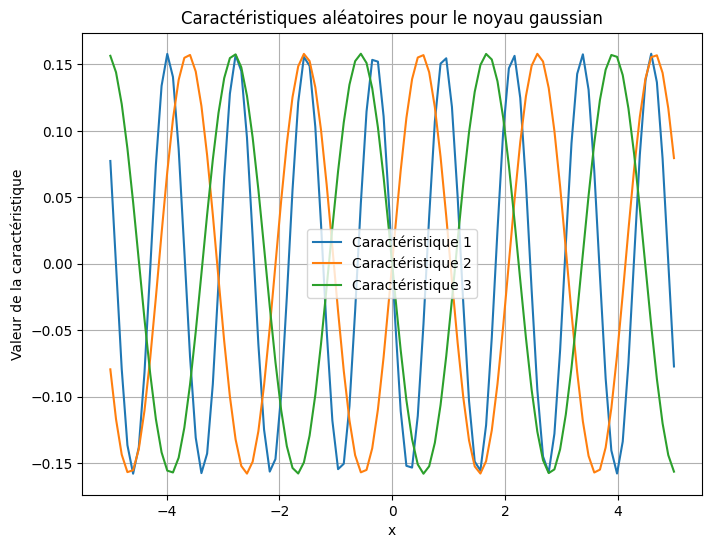

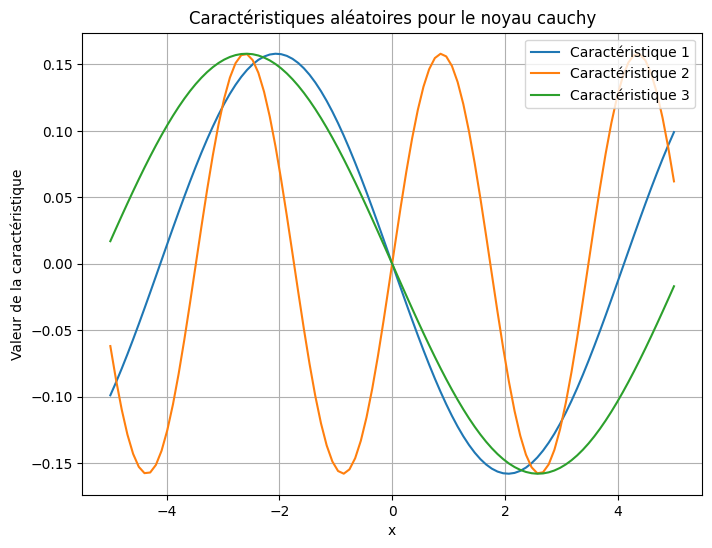

In [ ]:

# Fonction pour générer des caractéristiques de Fourier aléatoires
def rff(X, kernel, D):
    if kernel == 'gaussian':
        omega = np.random.normal(size=(D, X.shape[1]))
    elif kernel == 'laplacian':
        omega = np.random.standard_cauchy(size=(D, X.shape[1]))
    elif kernel == 'cauchy':
        omega = np.random.laplace(size=(D, X.shape[1]))
    else:
        raise ValueError("Type de noyau non supporté")
    return omega



# Fonction pour tracer les caractéristiques aléatoires
def plot(omega, kernel, num=3):
    x = np.linspace(-5, 5, 100).reshape(-1, 1)

    plt.figure(figsize=(8, 6))
    for i in range(num):
        # Application des transformations  caractéristiques
        feat = np.cos(x @ omega[i].reshape(1, -1)) * np.sin(x @ omega[i].reshape(1, -1))
        feat *= np.sqrt(1 / D)

        # Trace des fonction caractéristiques
        plt.plot(x, feat[:, 0], label=f"Caractéristique {i + 1}")

    plt.title(f"Caractéristiques aléatoires pour le noyau {kernel}")
    plt.xlabel("x")
    plt.ylabel("Valeur de la caractéristique")
    plt.legend()
    plt.grid(True)
    plt.show()

# Chargement des données
data = fetch_california_housing()
X = data.data
y = data.target

# Division
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Nombre de caractéristiques aléatoires
D = 10

# Généreration des vecteurs aléatores
omega_gauss = rff(X_train, kernel='gaussian', D=D)
omega_cauchy = rff(X_train, kernel='cauchy', D=D)
#Graphe
plot(omega_gauss, kernel='gaussian')
plot(omega_cauchy, kernel='cauchy')


Transformation des données

In [ ]:
#Noyaux
kernels = ['gaussian', 'laplacian', 'cauchy']
omegas = {}
times = {}
for kernel in kernels:
    debut = time.time()
    omegas[kernel] = rff(X_train, kernel=kernel, D=D)
    times[kernel] = time.time() - debut

# Fonction pour transformer les données avec les caractéristiques de Fourier aléatoires
def transform(X, omega, D):
    n = X.shape[0]
    data = np.zeros((n, D))
    for i in range(n):
        data[i, :] = np.cos(X[i, :] @ omega.T) * np.sin(X[i, :] @ omega.T)
    data *= np.sqrt(1 / D)
    return data

# Transformation des données avec les noyaux
X_train_rff = {}
X_test_rff = {}
for kernel in kernels:
    X_train_rff[kernel] = transform(X_train, omegas[kernel], D)
    X_test_rff[kernel] = transform(X_test, omegas[kernel], D)

# Entraînement des données transformées pour chaque noyau
debut = time.time()
svr = SVR()
svr.fit(X_train, y_train)
time_original = time.time() - debut


# temps
times_rff = {}
mse_rff = {}
for kernel in kernels:
    debut = time.time()
    svr = SVR()
    svr.fit(X_train_rff[kernel], y_train)
    times_rff[kernel] =time.time()  - debut

#  temps de calcul
print(f"Temps CPU (données d'origine): {time_original} secondes")
for kernel in kernels:
    print(f"Temps CPU (caractéristiques de Fourier - {kernel}): {times_rff[kernel]} secondes")

Temps CPU (données d'origine): 10.465964317321777 secondes
Temps CPU (caractéristiques de Fourier - gaussian): 11.050832509994507 secondes
Temps CPU (caractéristiques de Fourier - laplacian): 11.028195858001709 secondes
Temps CPU (caractéristiques de Fourier - cauchy): 10.937426328659058 secondes
